In [3]:
import pandas as pd 
import numpy as np
df=pd.read_csv("../archive/results.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
# question 1:matches in the dataset
num_matches=len(df)
print(f"number of matches  {num_matches}")

number of matches  49287


In [5]:
# question 2:what is the earliest and latest year in the data
df['date'] = pd.to_datetime(df['date'])

earliest_year = df['date'].min().year
latest_year = df['date'].max().year

print("Earliest year:", earliest_year)
print("Latest year:", latest_year)

Earliest year: 1872
Latest year: 2026


In [6]:
# question 3:unique countries
unique_countries=df['country'].unique()
print(f"unique countries {unique_countries}")

unique countries <StringArray>
[                'Scotland',                  'England',
                    'Wales',                  'Ireland',
            'United States',                  'Uruguay',
                  'Austria',                  'Hungary',
                'Argentina',                  'Belgium',
 ...
               'Montenegro', 'Northern Mariana Islands',
                  'Comoros', 'Turks and Caicos Islands',
              'South Sudan',         'Saint Barthélemy',
                   'Kosovo',              'Timor-Leste',
                 'Eswatini',                  'Bonaire']
Length: 269, dtype: str


In [7]:
# question 4:which team appears more frequently as home team
home_team=df['home_team'].value_counts().head(1)
print(f"team with more home apperances {home_team}")


team with more home apperances home_team
Brazil    614
Name: count, dtype: int64


In [8]:
# question 5: average number of goals per match
df['total_goals'] = df['home_score'] + df['away_score']

average_goals = df['total_goals'].mean()

print("Average goals per match:", average_goals)

Average goals per match: 2.93849436147516


In [9]:
# question 6:highest scoring match
df['total_goals'] = df['home_score'] + df['away_score']

highest_scoring_match = df.loc[df['total_goals'].idxmax()]

highest_scoring_match


date                    2001-04-11 00:00:00
home_team                         Australia
away_team                    American Samoa
home_score                             31.0
away_score                              0.0
tournament     FIFA World Cup qualification
city                          Coffs Harbour
country                           Australia
neutral                               False
total_goals                            31.0
Name: 25420, dtype: object

In [10]:
# question 7:more goals scored at home or away
total_home_goals = df['home_score'].sum()
total_away_goals = df['away_score'].sum()

print("Home goals:", total_home_goals)
print("Away goals:", total_away_goals)

Home goals: 86426.0
Away goals: 58192.0


In [11]:
# question 8:most common total goals value
df['total_goals'] = df['home_score'] + df['away_score']

most_common_total_goals = df['total_goals'].mode()[0]

print("Most common total goals per match:", most_common_total_goals)

Most common total goals per match: 2.0


In [12]:
#question 9 :what percentage of matches are home wins
home_wins = df[df['home_score'] > df['away_score']].shape[0]
total_matches = df.shape[0]

home_win_percentage = (home_wins / total_matches) * 100

print("Home win percentage:", home_win_percentage)

Home win percentage: 48.9094487390184


In [13]:
# question 10:does home advantage exists
home_win = (df['home_score'] > df['away_score']).mean()
away_win = (df['home_score'] < df['away_score']).mean()
draw = (df['home_score'] == df['away_score']).mean()

home_win, away_win, draw

(np.float64(0.489094487390184),
 np.float64(0.282265100330716),
 np.float64(0.22717958082252926))

In [14]:
# question 8:which country has more wins historically
import numpy as np

df['winner'] = np.where(
    df['home_score'] > df['away_score'], df['home_team'],
    np.where(df['home_score'] < df['away_score'], df['away_team'], 'Draw')
)
wins = df[df['winner'] != 'Draw']
win_counts = wins['winner'].value_counts()
win_counts.head(10)
most_wins_team = win_counts.idxmax()
most_wins_count = win_counts.max()

print("Most wins:", most_wins_team, most_wins_count)

Most wins: Brazil 670


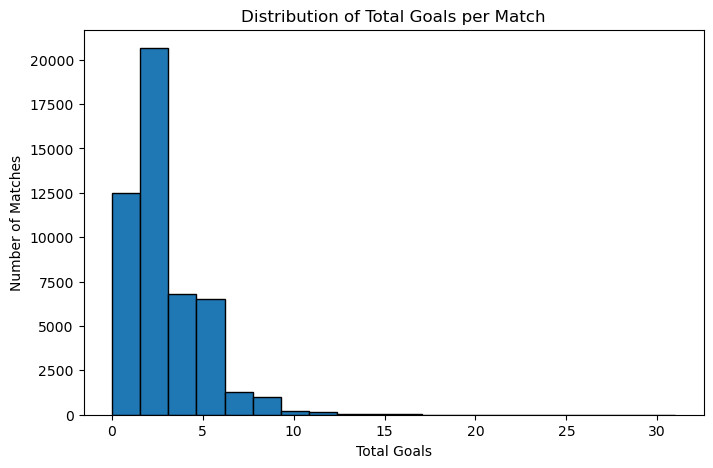

In [15]:
%matplotlib inline

import matplotlib.pyplot as plt

df['total_goals'] = df['home_score'] + df['away_score']

plt.figure(figsize=(8,5))
plt.hist(df['total_goals'].dropna(), bins=20, edgecolor='black')

plt.title("Distribution of Total Goals per Match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")

plt.show()

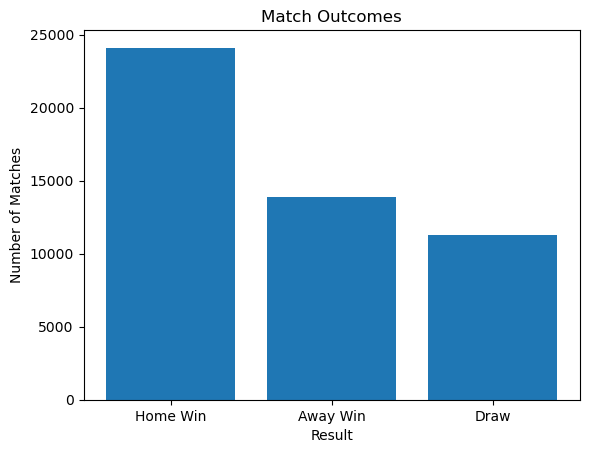

In [16]:
df['result'] = df.apply(
    lambda row: 'Home Win' if row['home_score'] > row['away_score']
    else ('Away Win' if row['home_score'] < row['away_score'] else 'Draw'),
    axis=1
)
outcome_counts = df['result'].value_counts()
plt.bar(outcome_counts.index, outcome_counts.values)
plt.title("Match Outcomes")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.show()

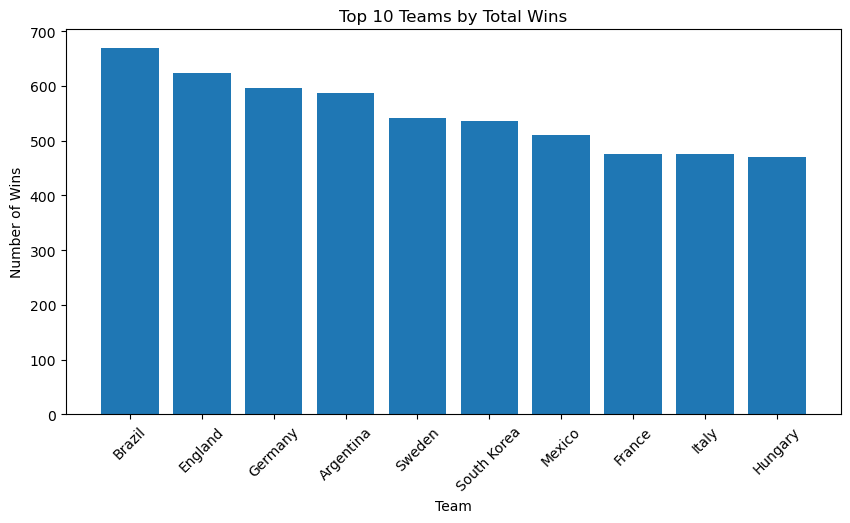

In [18]:
df['winner'] = df.apply(
    lambda row: row['home_team'] if row['home_score'] > row['away_score']
    else (row['away_team'] if row['away_score'] > row['home_score'] else 'Draw'),
    axis=1
)
wins = df[df['winner'] != 'Draw']
top_10_wins = wins['winner'].value_counts().head(10)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(top_10_wins.index, top_10_wins.values)

plt.title("Top 10 Teams by Total Wins")
plt.xlabel("Team")
plt.ylabel("Number of Wins")

plt.xticks(rotation=45)

plt.show()